# MNIST Neural Network (No TensorFlow)

This notebook trains a neural network on the MNIST dataset using **PyTorch**.
The model uses **categorical cross entropy (CrossEntropyLoss)** and plots **training loss across epochs**.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## Load MNIST Dataset

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

## Define Neural Network

In [6]:
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = MNISTModel()

## Loss Function and Optimizer

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Train the Model

In [8]:
epochs = 10
loss_history = []

for epoch in range(epochs):
    running_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/10, Loss: 0.3801
Epoch 2/10, Loss: 0.1897
Epoch 3/10, Loss: 0.1393
Epoch 4/10, Loss: 0.1113
Epoch 5/10, Loss: 0.0972
Epoch 6/10, Loss: 0.0844
Epoch 7/10, Loss: 0.0786
Epoch 8/10, Loss: 0.0684
Epoch 9/10, Loss: 0.0623
Epoch 10/10, Loss: 0.0580


## Plot Training Loss Across Epochs

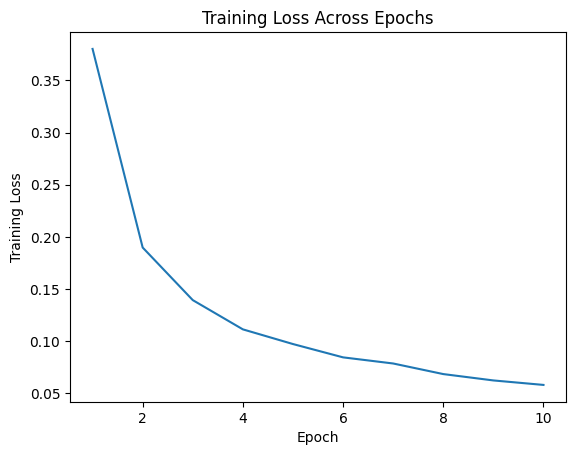

In [9]:
plt.figure()
plt.plot(range(1, epochs+1), loss_history)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Across Epochs')
plt.show()